# CPU Demo: YOLO + ResNet18 Fine-Tuning + PyTorch Lightning + ClearML

Полный цикл Computer Vision на CPU — от данных до эксперимента в ClearML.

## Что демонстрируем
| Блок | Задача | Данные | Фреймворк |
|------|--------|--------|-----------|
| 1 | **Object Detection** — fine-tune YOLO | Valentines Chocolates (22 класса, ~235 фото) | Ultralytics YOLOv8n |
| 2 | **Image Classification** — fine-tune ResNet18 | Fruits `codeur-rapide/images_yolo` (10 классов, 459 фото) | PyTorch (чистый) |
| 3 | Тот же ResNet18, чище | То же | PyTorch Lightning |
| ∀ | Логирование экспериментов, датасеты | — | **ClearML** |

> **CPU time estimate:** YOLO ≈ 2–3 мин · ResNet18×2 ≈ 1–2 мин · Lightning ≈ 1 мин

## 0) Импорты и инициализация ClearML

In [19]:
import csv
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision.models as tv_models
import torchvision.transforms as T

import lightning as L
from lightning.pytorch.callbacks import EarlyStopping

from ultralytics import YOLO
from datasets import load_dataset

from clearml import OutputModel, Task

# ── воспроизводимость ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")



Device: cuda


In [9]:
# ── ClearML: создаём единственный Task на весь ноутбук ────────────────────────
task = Task.init(
    project_name="AIS/Lecture07",
    task_name="gpu_demo_yolo_resnet18_lightning",
    reuse_last_task_id=False,
)
logger = task.get_logger()
print("ClearML Task ID:", task.id)

ClearML Task: created new task id=8c4a437af8644b398f15d816bd909131
ClearML results page: https://app.clear.ml/projects/54df5684574f4da78fb8ed5a55728688/experiments/8c4a437af8644b398f15d816bd909131/output/log
ClearML Task ID: 8c4a437af8644b398f15d816bd909131


█████████████████████████████████ 100% | 5.93/5.93 MB [00:00<00:00,  8.38MB/s]: 
█████████████████████████████████ 100% | 5.93/5.93 MB [00:02<00:00,  2.45MB/s]: 


---
## 1) YOLO fine-tuning — Valentines Chocolates (Object Detection)

Датасет: **235 фото** коробки See's Chocolates, **22 класса** шоколадных конфет.  
Источник: [Roboflow Universe](https://universe.roboflow.com/chocolates/valentines-chocolates/dataset/4) (CC BY 4.0).

Fine-tuning `yolov8n` (nano, ~3M параметров) — **1 epoch** для скорости на CPU.

Train images: 225
data_demo.yaml → /home/lupasic/Programs/AIS/lectures/07/extra_materials/data/yolo_custom/Valentines Chocolates.v4-fixed-annotations.yolov8/data_demo.yaml


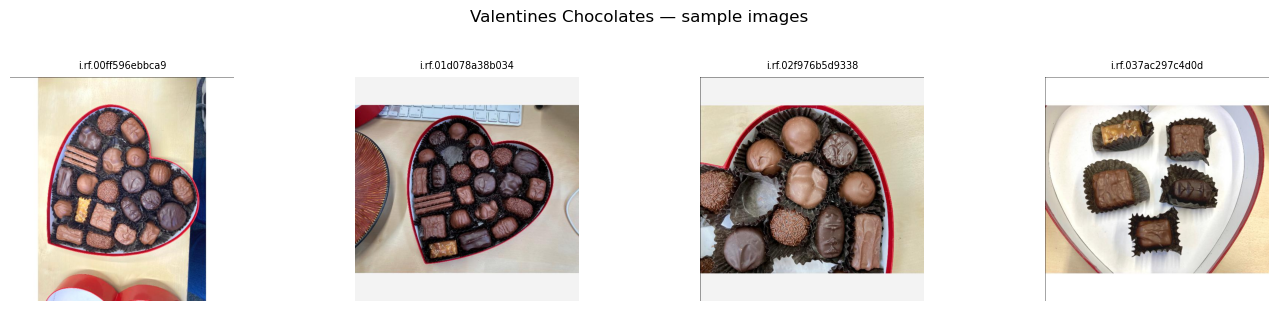

In [10]:
# ── Папки датасета ─────────────────────────────────────────────────────────────
DATA_DIR = Path("../data/yolo_custom/Valentines Chocolates.v4-fixed-annotations.yolov8").resolve()
IMAGES_TRAIN = DATA_DIR / "train" / "images"
LABELS_TRAIN = DATA_DIR / "train" / "labels"

jpg_count = len(list(IMAGES_TRAIN.glob("*.jpg")))
print(f"Train images: {jpg_count}")

# Классы из data.yaml
CLASS_NAMES = [
    "Dark Almond Nougat", "Dark Almonds", "Dark Bordeaux", "Dark Caramel Patties",
    "Dark Chocolate Buttercream", "Dark Marzipan", "Dark Normandie", "Dark Scotchmallow",
    "Dark Walnut Square", "Milk Almond Caramel", "Milk Almonds", "Milk Beverly",
    "Milk Bordeaux", "Milk Butterscotch Square", "Milk California Brittle", "Milk Chelsea",
    "Milk Chocolate Buttercream", "Milk Coconut Cream", "Milk Mayfair", "Milk Mocha",
    "Milk Molasses Chips", "Milk Rum Nougat",
]

# data_demo.yaml — val указываем на train (папки valid/ нет, нам нужна скорость)
YAML_DEMO = DATA_DIR / "data_demo.yaml"
YAML_DEMO.write_text(
    f"path: {DATA_DIR}\n"
    "train: train/images\n"
    "val:   train/images\n"
    f"nc: {len(CLASS_NAMES)}\n"
    f"names: {CLASS_NAMES}\n"
)
print("data_demo.yaml →", YAML_DEMO)

# ── Логируем метаданные датасета в ClearML ─────────────────────────────────────
task.connect({
    "name":            "Valentines Chocolates YOLOv8",
    "source":          "Roboflow (CC BY 4.0)",
    "task_type":       "object_detection",
    "num_classes":     len(CLASS_NAMES),
    "num_train_imgs":  jpg_count,
}, name="yolo_dataset_info")

# ── Превью: первые 4 картинки ──────────────────────────────────────────────────
sample_paths = sorted(IMAGES_TRAIN.glob("*.jpg"))[:4]
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, p in zip(axes, sample_paths):
    ax.imshow(Image.open(p))
    ax.set_title(p.stem[:18], fontsize=7)
    ax.axis("off")
plt.suptitle("Valentines Chocolates — sample images", y=1.02)
plt.tight_layout()
plt.show()

In [11]:
torch.cuda.is_available()

True

New https://pypi.org/project/ultralytics/8.4.27 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.14.3 torch-2.10.0 CUDA:1 (NVIDIA GeForce RTX 2080 Ti, 11009MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=50, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/lupasic/Programs/AIS/lectures/07/extra_materials/data/yolo_custom/Valentines Chocolates.v4-fixed-annotations.yolov8/data_demo.yaml, degrees=0.0, deterministic=True, device=1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max

█████████████████████████████████ 100% | 5.93/5.93 MB [00:00<00:00, 11.66MB/s]: 


Registered YOLO output model: /home/lupasic/Programs/AIS/runs/runs/yolo_chocolates_cpu/weights/best.pt
YOLO training done. Save dir: /home/lupasic/Programs/AIS/runs/runs/yolo_chocolates_cpu


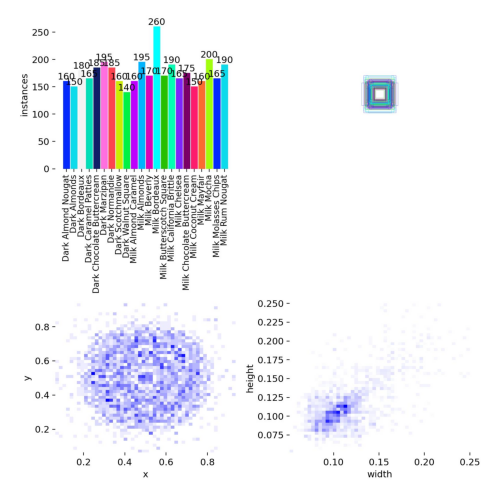

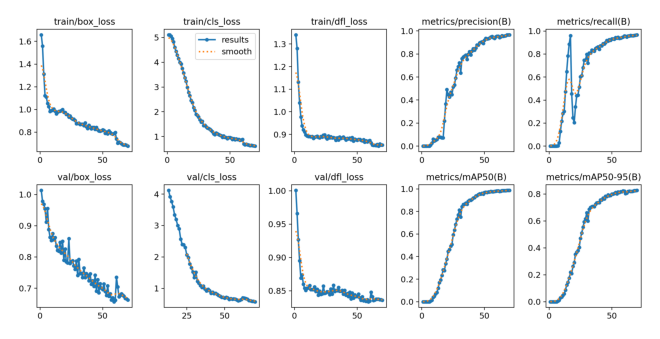

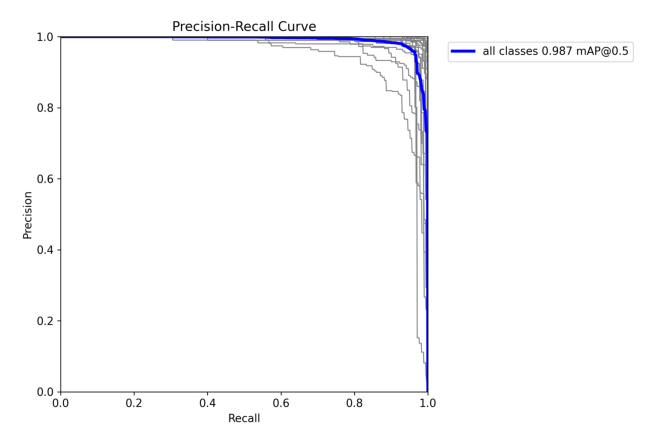

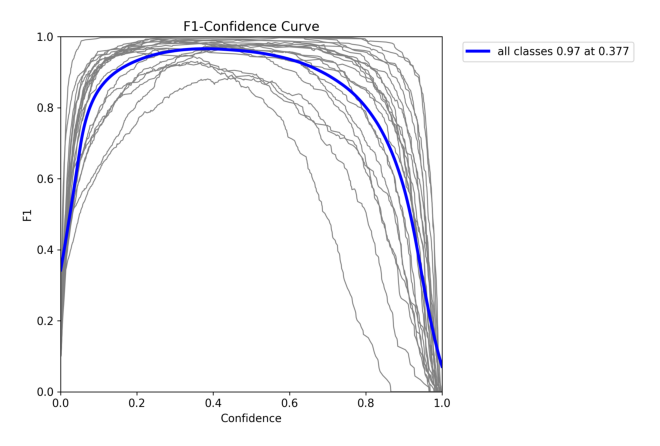

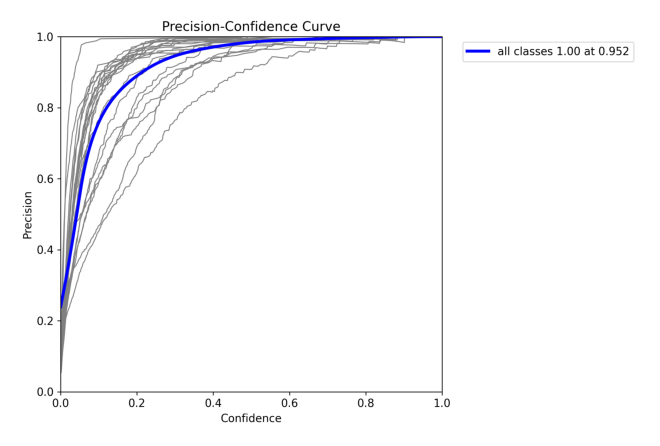

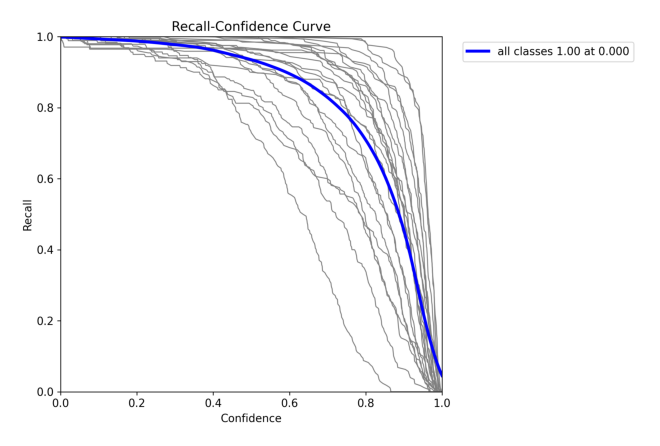

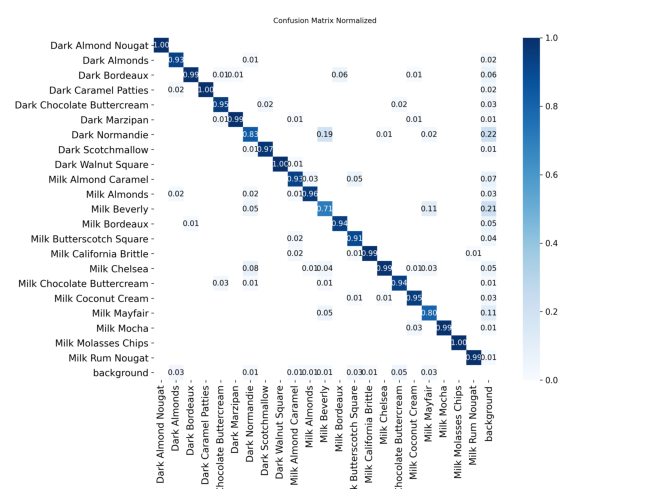

In [12]:
# ── Fine-tune YOLOv8n (3 epochs, CPU) ──────────────────────────────────────────
yolo_hparams = {
    "epochs": 70,
    "imgsz": 320,
    "batch": 50,
    "device": "1" if torch.cuda.is_available() else "cpu",
    "workers": 0,
    "project": "../runs",
    "name": "yolo_chocolates_cpu",
    "verbose": True,
    "exist_ok": True,
}
task.connect(yolo_hparams, name="yolo_hparams")

yolo_model = YOLO("yolov8n.pt")

train_results = yolo_model.train(
    data=str(YAML_DEMO),
    **yolo_hparams,
)

yolo_save_dir = Path(train_results.save_dir)
results_csv = yolo_save_dir / "results.csv"
best_weights = yolo_save_dir / "weights" / "best.pt"
last_weights = yolo_save_dir / "weights" / "last.pt"

if results_csv.exists():
    with results_csv.open(newline="") as fp:
        reader = csv.DictReader(fp)
        for iteration, row in enumerate(reader, start=1):
            for key, value in row.items():
                metric_name = key.strip()
                if metric_name == "epoch" or value in ("", None):
                    continue
                try:
                    logger.report_scalar("yolo/train", metric_name, iteration=iteration, value=float(value))
                except (TypeError, ValueError):
                    pass

artifact_paths = {
    "yolo_results_csv": results_csv,
    "yolo_args_yaml": yolo_save_dir / "args.yaml",
    "yolo_results_png": yolo_save_dir / "results.png",
    "yolo_labels_jpg": yolo_save_dir / "labels.jpg",
    "yolo_best_weights": best_weights,
    "yolo_last_weights": last_weights,
}
for artifact_name, artifact_path in artifact_paths.items():
    if artifact_path.exists():
        task.upload_artifact(name=artifact_name, artifact_object=str(artifact_path))

if best_weights.exists():
    yolo_output_model = OutputModel(task=task, name="yolov8n-valentines-chocolates")
    yolo_output_model.update_weights(weights_filename=str(best_weights), auto_delete_file=False)
    print(f"Registered YOLO output model: {best_weights}")
else:
    print("YOLO training finished, but best.pt was not found.")

metrics = train_results.results_dict if hasattr(train_results, "results_dict") else {}
for k, v in metrics.items():
    try:
        logger.report_scalar("yolo/final", k, iteration=yolo_hparams["epochs"], value=float(v))
    except (TypeError, ValueError):
        pass

print(f"YOLO training done. Save dir: {yolo_save_dir}")

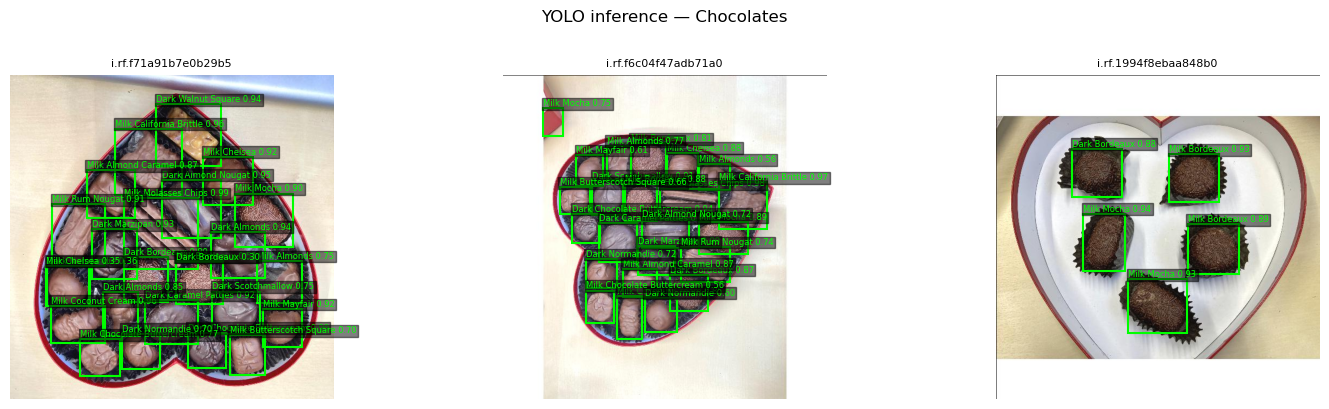

In [13]:
# ── Inference на трёх случайных картинках ──────────────────────────────────────
sample_imgs = random.sample(sorted(IMAGES_TRAIN.glob("*.jpg")), 3)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, img_path in zip(axes, sample_imgs):
    results = yolo_model.predict(str(img_path), device="gpu", imgsz=320, conf=0.25, verbose=False)
    res = results[0]

    img_arr = np.array(Image.open(img_path))
    ax.imshow(img_arr)

    if res.boxes is not None:
        for box in res.boxes:
            cls_id = int(box.cls.item())
            conf   = box.conf.item()
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            rect = mpatches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=1.5, edgecolor="lime", facecolor="none",
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, f"{CLASS_NAMES[cls_id]} {conf:.2f}",
                    fontsize=6, color="lime",
                    bbox=dict(facecolor="black", alpha=0.5, pad=1))

    ax.set_title(img_path.name[:20], fontsize=8)
    ax.axis("off")

plt.suptitle("YOLO inference — Chocolates", y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# Закрываем Task только после всех report_* / upload_artifact / update_weights
# После task.close() новые логи к этой задаче уже не прикрепляются.
task.close()
print("ClearML task closed. Open the UI to review metrics, artifacts, and models.")

ClearML task closed. Open the UI to review metrics, artifacts, and models.


---
## 2) ResNet18 fine-tuning — Fruits Classification (PyTorch)

Датасет: **`codeur-rapide/images_yolo`** с HuggingFace — 459 фото, **10 классов фруктов**.  
Модель: `ResNet18` (ImageNet pretrained).  
Стратегия: **заморозим все слои, обучим только последний FC** → быстро на CPU.
- Меняем `model.fc = nn.Linear(512, 10)`
- Оптимизируем только `model.fc.parameters()`

In [ ]:
# ── ClearML: создаём единственный Task на весь ноутбук ────────────────────────
task = Task.init(
    project_name="AIS/Lecture07",
    task_name="gpu_demo_resnet18_pytorch",
    reuse_last_task_id=False,
)
logger = task.get_logger()
print("ClearML Task ID:", task.id)

ClearML Task: created new task id=c7d015a66b384d0282161f27fa107609
ClearML results page: https://app.clear.ml/projects/54df5684574f4da78fb8ed5a55728688/experiments/c7d015a66b384d0282161f27fa107609/output/log
ClearML Task ID: c7d015a66b384d0282161f27fa107609


█████████████████████████████████ 100% | 5.36/5.36 MB [00:00<00:00,  7.18MB/s]: 
█████████████████████████████████ 100% | 5.36/5.36 MB [00:00<00:00,  8.20MB/s]: 


ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


███████████████████████████████ 100% | 42.73/42.73 MB [00:02<00:00, 18.67MB/s]: 


Resolving data files:   0%|          | 0/459 [00:00<?, ?it/s]

Classes (10): ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit', 'grapes fruit', 'images 2', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']
Total images: 459


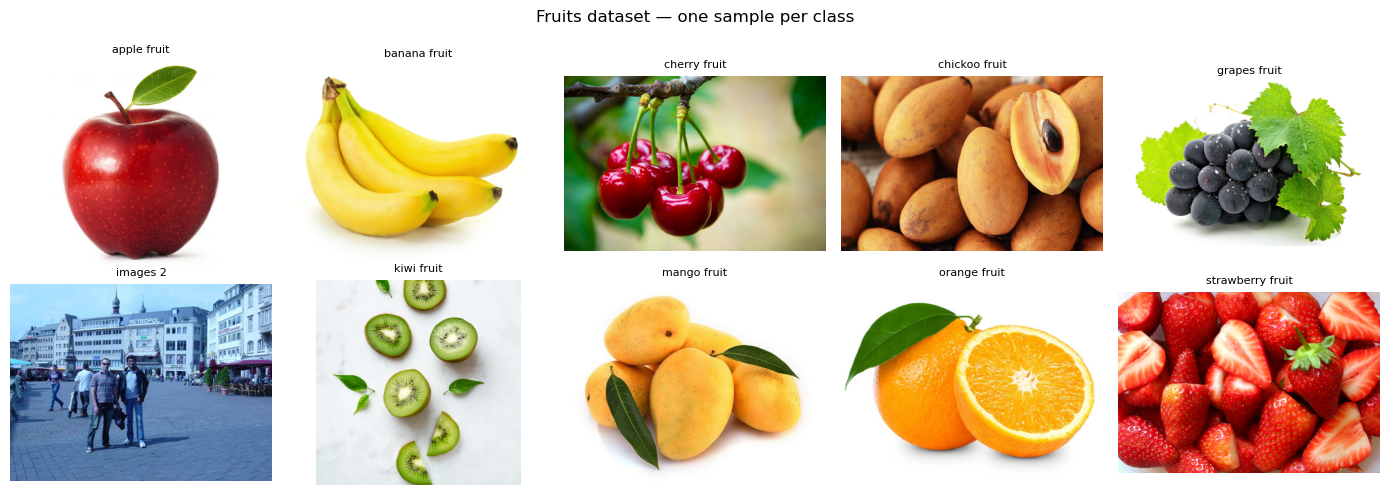

In [20]:
# ── Загрузка датасета с HuggingFace ───────────────────────────────────────────
hf_ds = load_dataset("codeur-rapide/images_yolo", split="train")

FRUIT_CLASSES = hf_ds.features["label"].names
NUM_CLASSES   = len(FRUIT_CLASSES)
print(f"Classes ({NUM_CLASSES}): {FRUIT_CLASSES}")
print(f"Total images: {len(hf_ds)}")

# ── Логируем в ClearML ─────────────────────────────────────────────────────────
task.connect({
    "name":         "codeur-rapide/images_yolo",
    "source":       "HuggingFace",
    "task_type":    "image_classification",
    "num_classes":  NUM_CLASSES,
    "class_names":  FRUIT_CLASSES,
    "num_images":   len(hf_ds),
}, name="fruits_dataset_info")

# ── Превью: по одному фото каждого класса ──────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
shown = {}
for item in hf_ds:
    lbl = item["label"]
    if lbl not in shown:
        shown[lbl] = item["image"]
    if len(shown) == NUM_CLASSES:
        break

for ax, (lbl, img) in zip(axes.flatten(), sorted(shown.items())):
    ax.imshow(img)
    ax.set_title(FRUIT_CLASSES[lbl], fontsize=8)
    ax.axis("off")
plt.suptitle("Fruits dataset — one sample per class")
plt.tight_layout()
plt.show()

In [21]:
# ── Датасет PyTorch обёртка ────────────────────────────────────────────────────
class FruitDataset(Dataset):
    """Тонкая обёртка над HuggingFace dataset. Применяет torchvision transforms."""
    def __init__(self, hf_dataset, indices, transform):
        self.hf = hf_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        item = self.hf[int(self.indices[idx])]
        return self.transform(item["image"].convert("RGB")), item["label"]


TRAIN_TRANSFORM = T.Compose([
    T.Resize((128, 128)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),   # ImageNet stats
])
VAL_TRANSFORM = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ── Стратифицированный сплит 80/20 ────────────────────────────────────────────
all_idx = list(range(len(hf_ds)))
labels  = [hf_ds[i]["label"] for i in all_idx]

try:
    from sklearn.model_selection import train_test_split as sk_split
    train_idx, val_idx = sk_split(all_idx, test_size=0.2, stratify=labels, random_state=SEED)
except ImportError:
    split = int(len(all_idx) * 0.8)
    train_idx, val_idx = all_idx[:split], all_idx[split:]

train_ds = FruitDataset(hf_ds, train_idx, TRAIN_TRANSFORM)
val_ds   = FruitDataset(hf_ds, val_idx,   VAL_TRANSFORM)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

# ── ResNet18: загрузка + заморозка ────────────────────────────────────────────
weights  = tv_models.ResNet18_Weights.IMAGENET1K_V1
resnet18 = tv_models.resnet18(weights=weights)

for param in resnet18.parameters():
    param.requires_grad = False

resnet18.fc = nn.Linear(resnet18.fc.in_features, NUM_CLASSES)  # 512 → 10
resnet18 = resnet18.to(DEVICE)
print("Trainable params:", sum(p.numel() for p in resnet18.parameters() if p.requires_grad))

Train: 367 | Val: 92


Connecting multiple input models with the same name: `resnet18-f37072fd`. This might result in the wrong model being used when executing remotely


Trainable params: 5130


In [22]:
# ── Чистый PyTorch training loop ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18.fc.parameters(), lr=1e-3)

EPOCHS = 2
task.connect({"lr": 1e-3, "epochs": EPOCHS, "batch_size": 32, "img_size": 128}, name="pytorch_hparams")

global_step = 0
for epoch in range(EPOCHS):
    resnet18.train()
    epoch_loss = 0.0
    for step, (imgs, lbls) in enumerate(train_loader):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(resnet18(imgs), lbls)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        logger.report_scalar("pytorch/train_loss", "loss", iteration=global_step, value=loss.item())
        global_step += 1

    # Validation accuracy
    resnet18.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            preds = resnet18(imgs).argmax(dim=1)
            correct += (preds == lbls).sum().item()
            total += lbls.size(0)
    val_acc = correct / total
    avg_loss = epoch_loss / len(train_loader)
    logger.report_scalar("pytorch/val_acc", "acc", iteration=epoch, value=val_acc)
    logger.report_scalar("pytorch/avg_loss", "loss", iteration=epoch, value=avg_loss)
    print(f"[PyTorch] epoch {epoch+1}/{EPOCHS}  loss={avg_loss:.4f}  val_acc={val_acc:.3f}")

pytorch_model_path = Path("../runs/resnet18_pytorch_cpu_state_dict.pt").resolve()
pytorch_model_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(resnet18.state_dict(), pytorch_model_path)

pytorch_output_model = OutputModel(task=task, name="resnet18-fruits-pytorch")
pytorch_output_model.update_weights(weights_filename=str(pytorch_model_path), auto_delete_file=False)
task.upload_artifact(name="resnet18_pytorch_state_dict", artifact_object=str(pytorch_model_path))

print(f"PyTorch fine-tuning done. Saved weights to {pytorch_model_path}")

[PyTorch] epoch 1/2  loss=2.1826  val_acc=0.630
[PyTorch] epoch 2/2  loss=1.3018  val_acc=0.750
PyTorch fine-tuning done. Saved weights to /home/lupasic/Programs/AIS/lectures/07/extra_materials/runs/resnet18_pytorch_cpu_state_dict.pt


### Как связать YOLO training с ClearML

Ниже мы не просто запускаем `yolo_model.train(...)`, а ещё:
- логируем гиперпараметры YOLO в ClearML через `task.connect(...)`
- публикуем выходную папку обучения как артефакт
- загружаем `best.pt` как выходную модель эксперимента
- отдельно отправляем итоговые метрики в ClearML

Важно: часть графиков появится автоматически, потому что ClearML перехватывает stdout/stderr, Matplotlib и отчёты логгеров фреймворков.

---
## 3) Тот же ResNet18, но через PyTorch Lightning

Lightning убирает boilerplate:  
- нет ручных `optimizer.zero_grad()` / `loss.backward()` / `optimizer.step()`  
- нет ручного `.train()` / `.eval()`  
- встроенная поддержка колбеков, мультиGPU, mixed precision, логгеров и т.д.

In [ ]:
class LitResNet18(L.LightningModule):
    """ResNet18 с замороженным backbone. Обучаем только FC-слой."""

    def __init__(self, num_classes: int = 10, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters()

        weights = tv_models.ResNet18_Weights.IMAGENET1K_V1
        backbone = tv_models.resnet18(weights=weights)
        for p in backbone.parameters():
            p.requires_grad = False
        backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)
        self.model = backbone
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, _):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def configure_optimizers(self):
        return optim.Adam(self.model.fc.parameters(), lr=self.hparams.lr)


lit_model = LitResNet18(num_classes=NUM_CLASSES, lr=1e-3)
task.connect({"lr": 1e-3, "epochs": 3, "log_every_n_steps": 5}, name="lightning_hparams")

trainer = L.Trainer(
    accelerator="cpu",
    devices=1,
    max_epochs=3,
    log_every_n_steps=5,
    callbacks=[EarlyStopping(monitor="val_loss", patience=2, verbose=True)],
    enable_checkpointing=False,
    deterministic=True,
)

trainer.fit(lit_model, train_loader, val_loader)

# Финальные метрики → ClearML
final = trainer.callback_metrics
for k, v in final.items():
    logger.report_scalar("lightning", k, iteration=trainer.current_epoch, value=float(v))

lightning_ckpt_path = Path("../runs/resnet18_lightning_cpu.ckpt").resolve()
lightning_ckpt_path.parent.mkdir(parents=True, exist_ok=True)
trainer.save_checkpoint(str(lightning_ckpt_path))

lightning_output_model = OutputModel(task=task, name="resnet18-fruits-lightning")
lightning_output_model.update_weights(weights_filename=str(lightning_ckpt_path), auto_delete_file=False)
task.upload_artifact(name="resnet18_lightning_checkpoint", artifact_object=str(lightning_ckpt_path))

print(f"Lightning training done. Saved checkpoint to {lightning_ckpt_path}")

---
## 4) Итоги эксперимента — открываем ClearML UI

После запуска всего ноутбука в ClearML появится задача **`cpu_demo_yolo_resnet18_lightning`**  
с графиками `pytorch/train_loss`, `pytorch/val_acc`, `lightning/val_loss`, `lightning/val_acc`, `yolo/train` и параметрами всех трёх запусков.

Что здесь попадает в ClearML вручную:
- `task.connect(...)` — гиперпараметры и метаданные датасетов
- `logger.report_scalar(...)` — численные метрики и графики
- `task.upload_artifact(...)` / `OutputModel.update_weights(...)` — артефакты и обученные веса

Что попадает автоматически после `Task.init(...)`:
- stdout/stderr из ноутбука и библиотек
- Matplotlib-графики, показанные через `plt.show()`
- notebook output, который ClearML умеет перехватывать в Jupyter

Важно: `task.close()` вызываем только в самом конце, когда все `report_*`, `upload_artifact(...)` и `update_weights(...)` уже завершены.

```
Открыть: http://localhost:8080  (или ваш сервер ClearML)
Проект:  AIS/Lecture07
```

In [23]:
# Закрываем Task только после всех report_* / upload_artifact / update_weights
# После task.close() новые логи к этой задаче уже не прикрепляются.
task.close()
print("ClearML task closed. Open the UI to review metrics, artifacts, and models.")

ClearML task closed. Open the UI to review metrics, artifacts, and models.
